In [18]:
import os
import sys
import pandas as pd

# 1. Locate the project root (parent of the 'notebooks' directory)
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(os.path.abspath("../"))

# 2. Add the 'src' directory to the system path so Python can find your module
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# 3. Import your function (matches the filename src/data_loader.py)
from src.data_loader import fetch_and_save_data

# 4. Define the correct absolute path to data/raw from the project root

processed_dir = os.path.join(project_root, 'data', 'processed')
print(processed_dir)

# Ensure the processed directory exists
os.makedirs(processed_dir, exist_ok=True)

tickers = ['TSLA', 'BND', 'SPY']
dataframes = {}

c:\Users\Hermela\Desktop\10academy\week 9\data\processed


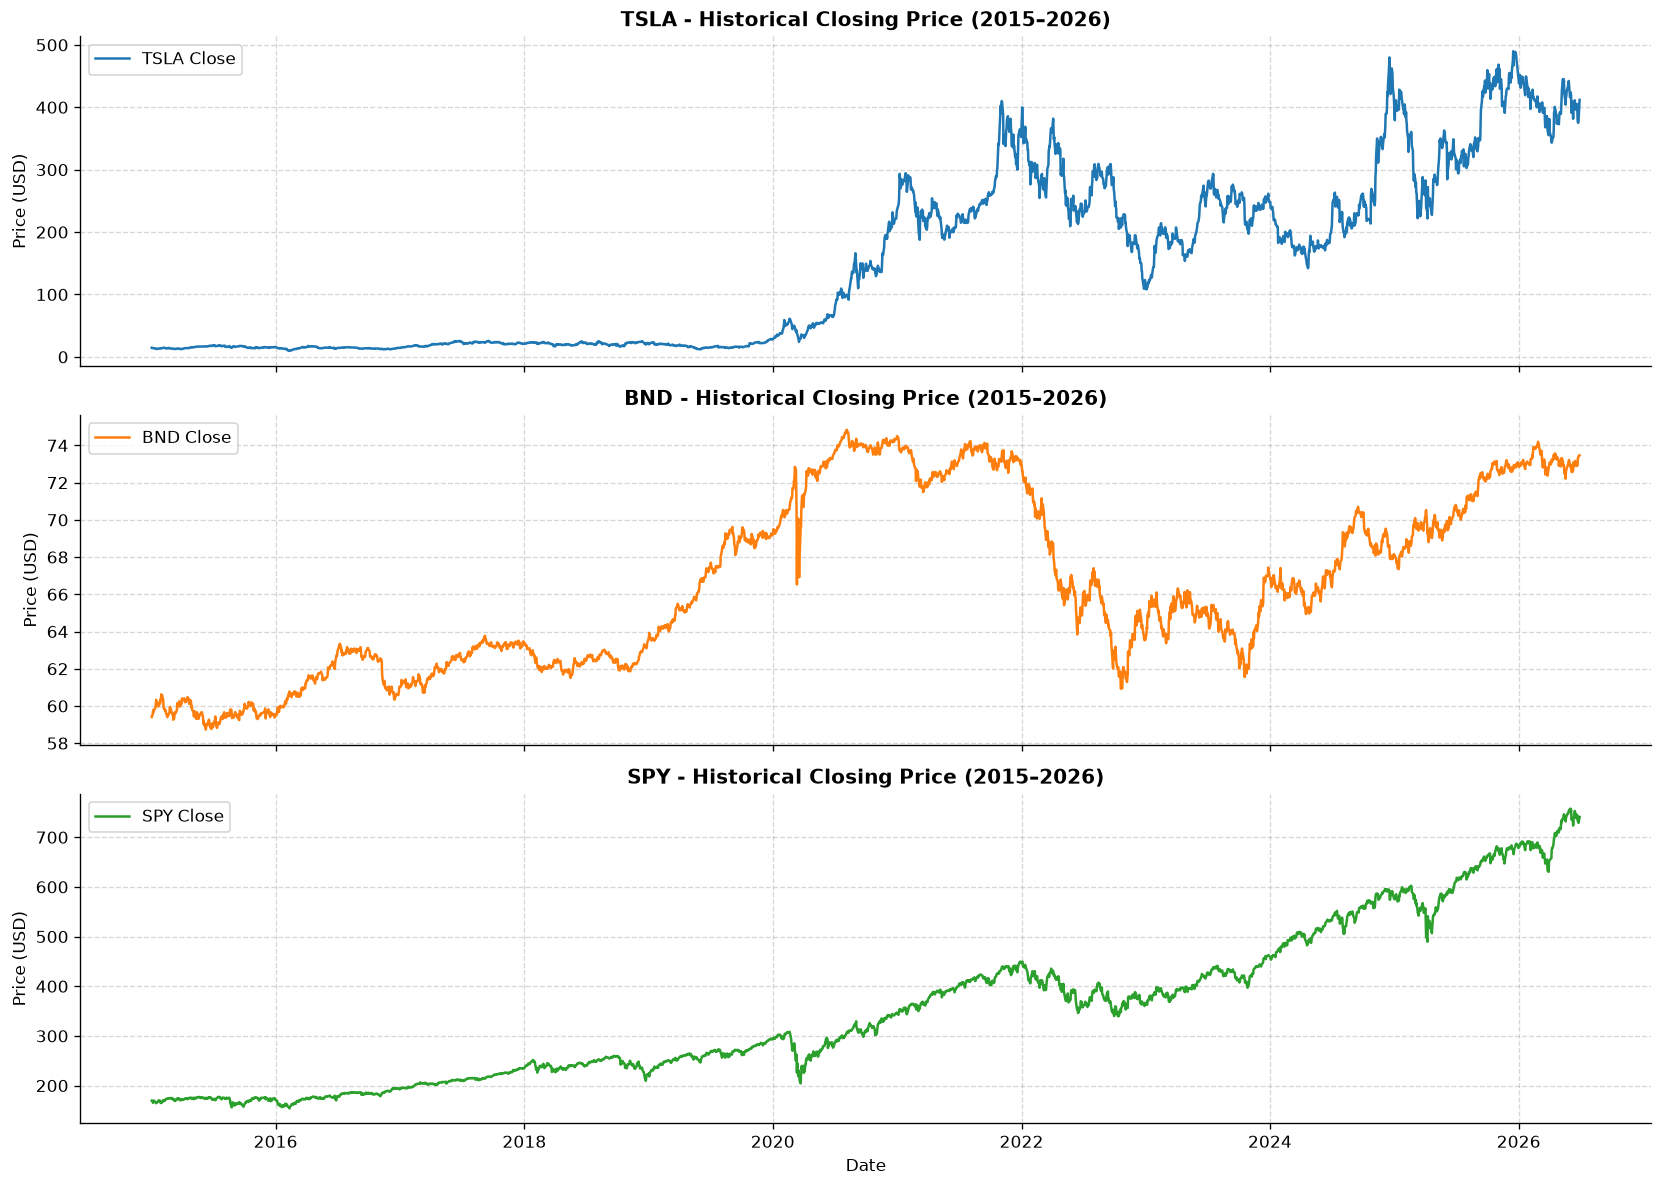

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# 1. Set up the subplots layout (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 2. Use enumerate to get both the index (i) and the stock symbol (ticker)
for i, ticker in enumerate(tickers):
    file_path = os.path.join(processed_dir, f"{ticker}_cleaned.csv")
    
    if os.path.exists(file_path):
        # Read CSV and immediately force 'Date' to be the datetime index
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        
        # Save it to your dataframes dictionary so it's available for later cells
        dataframes[ticker] = df
        
        # Target the specific subplot array element using axes[i]
        axes[i].plot(df.index, df['Close'], label=f"{ticker} Close", color=f"C{i}", linewidth=1.5)
        axes[i].set_title(f"{ticker} - Historical Closing Price (2015–2026)", fontsize=12, fontweight='bold')
        axes[i].set_ylabel("Price (USD)")
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(loc="upper left")
    else:
        print(f"File not found: {file_path}")

# 3. Apply global adjustments outside the loop after all subplots are filled
plt.xlabel("Date")
plt.tight_layout()
plt.show()

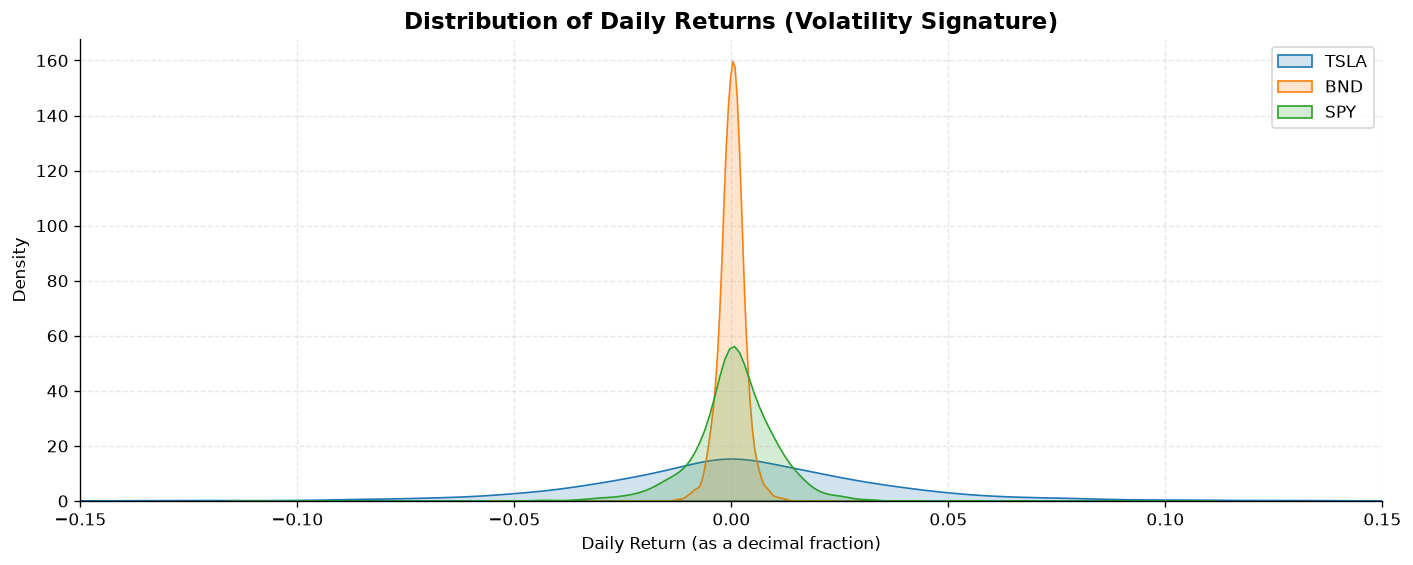

In [20]:
# Calculate daily returns for all assets
for ticker in tickers:
    dataframes[ticker]['Daily_Return'] = dataframes[ticker]['Close'].pct_change()

# Plot the distribution histograms of daily returns
plt.figure(figsize=(14, 5))
for i, ticker in enumerate(tickers):
    sns.kdeplot(dataframes[ticker]['Daily_Return'].dropna(), label=ticker, fill=True, alpha=0.2)

plt.title("Distribution of Daily Returns (Volatility Signature)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return (as a decimal fraction)")
plt.ylabel("Density")
plt.xlim(-0.15, 0.15) # zoom into the main bulk of daily movements
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.show()

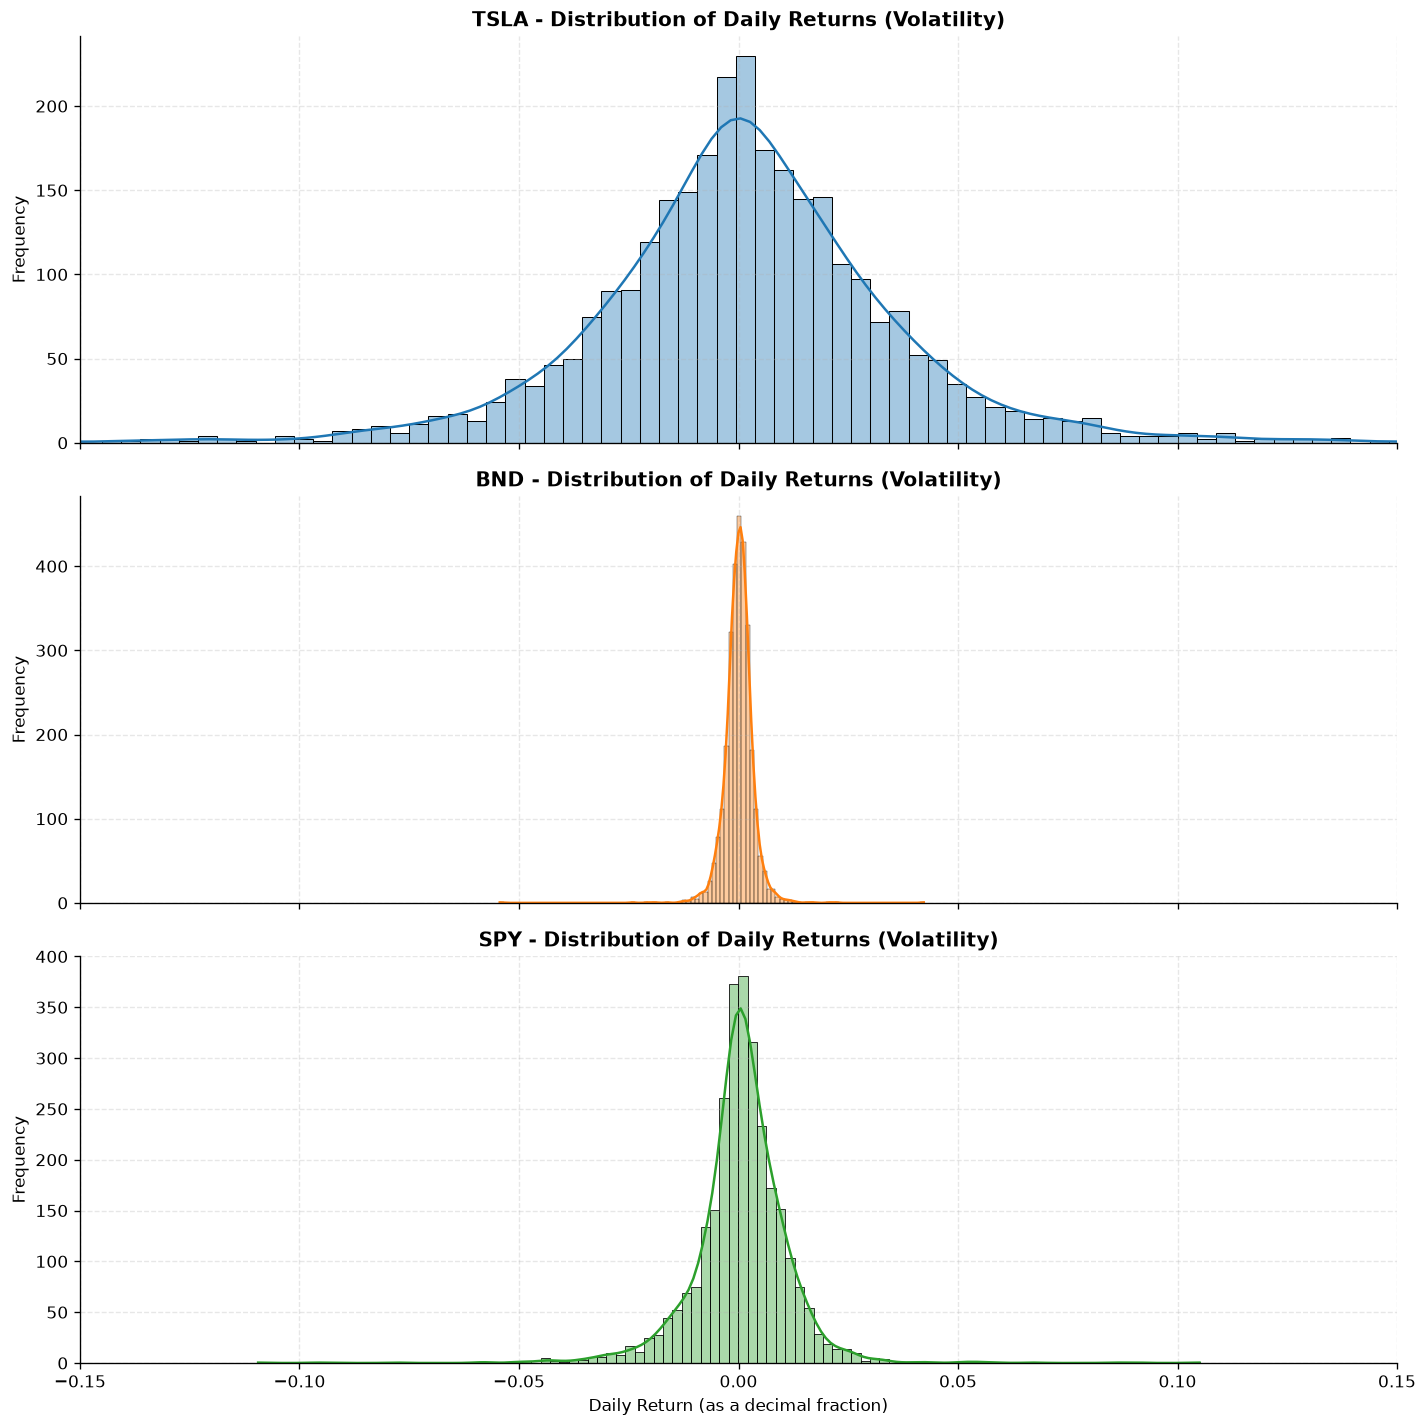

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate daily returns for all assets first
for ticker in tickers:
    dataframes[ticker]['Daily_Return'] = dataframes[ticker]['Close'].pct_change()

# Create separate subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for i, ticker in enumerate(tickers):
    # Drop missing values (the first day will always be NaN for pct_change)
    clean_returns = dataframes[ticker]['Daily_Return'].dropna()
    
    # Plot a histogram combined with a KDE curve for each stock
    sns.histplot(clean_returns, bins=100, kde=True, ax=axes[i], color=f"C{i}", alpha=0.4)
    
    axes[i].set_title(f"{ticker} - Distribution of Daily Returns (Volatility)", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True, linestyle='--', alpha=0.3)
    
    # Zoom in slightly to ignore massive, one-off outliers and see the main bulk
    axes[i].set_xlim(-0.15, 0.15) 

plt.xlabel("Daily Return (as a decimal fraction)")
plt.tight_layout()
plt.show()

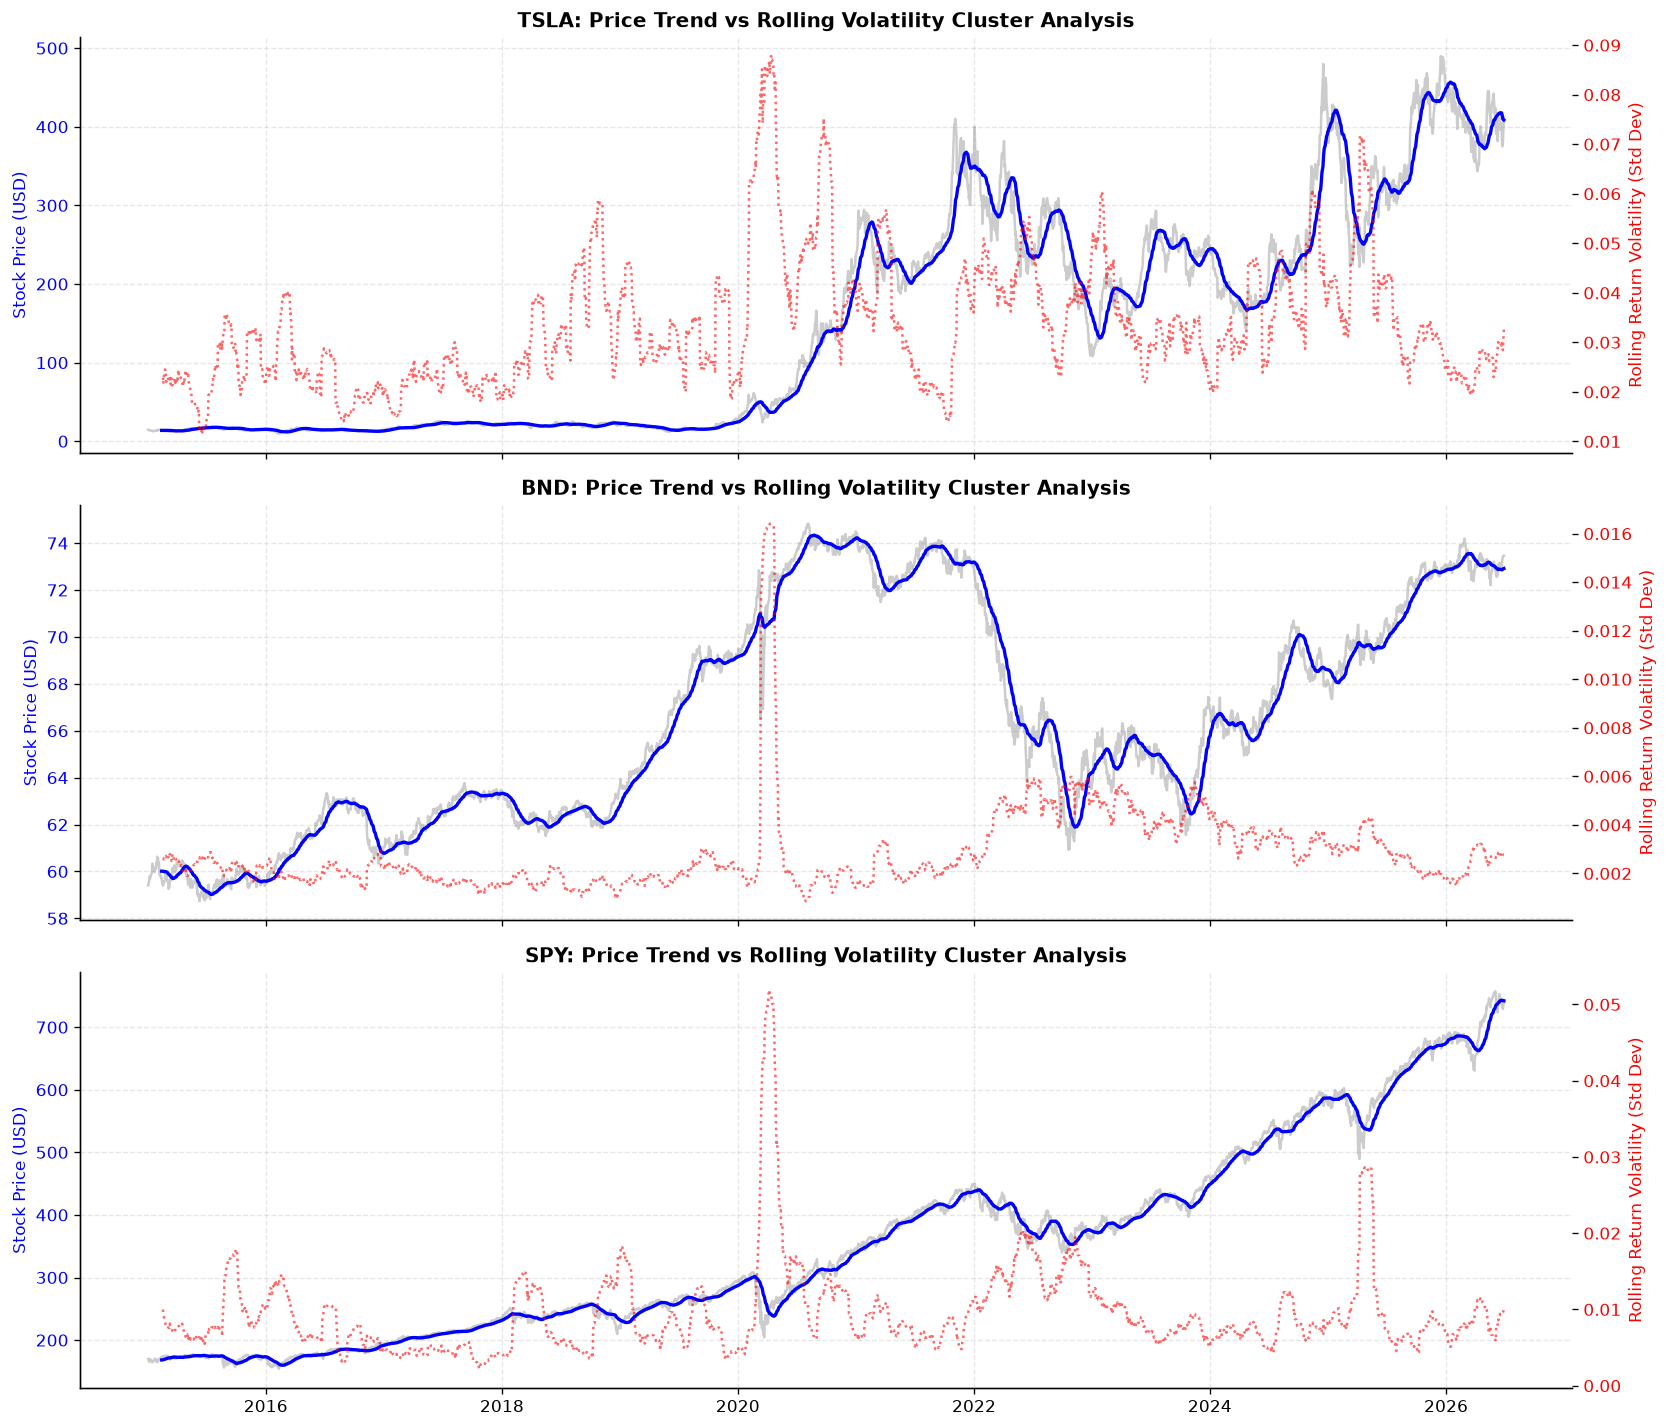

In [22]:
# We use a 30-day rolling window to capture short-term monthly fluctuations
WINDOW = 30

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, ticker in enumerate(tickers):
    df = dataframes[ticker]
    
    # Calculate Rolling Mean and Rolling Standard Deviation (Volatility)
    rolling_mean = df['Close'].rolling(window=WINDOW).mean()
    rolling_std = df['Daily_Return'].rolling(window=WINDOW).std()
    
    # Left Axis: Price and Rolling Mean
    ax1 = axes[i]
    ax1.plot(df.index, df['Close'], alpha=0.4, label="Daily Close", color="gray")
    ax1.plot(df.index, rolling_mean, label=f"{WINDOW}-Day Rolling Mean", color="blue", linewidth=2)
    ax1.set_ylabel("Stock Price (USD)", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")
    
    # Right Axis: Share the same x-axis but plot rolling volatility
    ax2 = ax1.twinx()
    ax2.plot(df.index, rolling_std, label=f"{WINDOW}-Day Rolling Volatility", color="red", alpha=0.6, linestyle=':')
    ax2.set_ylabel("Rolling Return Volatility (Std Dev)", color="red")
    ax2.tick_params(axis='y', labelcolor="red")
    
    ax1.set_title(f"{ticker}: Price Trend vs Rolling Volatility Cluster Analysis", fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [23]:
# Outlier definition: Daily returns greater or less than 3 standard deviations from the mean
THRESHOLD = 3

for ticker in tickers:
    df = dataframes[ticker].dropna()
    mean_ret = df['Daily_Return'].mean()
    std_ret = df['Daily_Return'].std()
    
    # Identify index locations of anomalies
    outliers = df[(df['Daily_Return'] > mean_ret + THRESHOLD * std_ret) | 
                  (df['Daily_Return'] < mean_ret - THRESHOLD * std_ret)]
    
    print(f"\n{ticker} - Detected {len(outliers)} market anomaly outliers out of {len(df)} trading days.")
    # Show the top 3 biggest positive and negative shock days
    display(outliers[['Close', 'Daily_Return']].sort_values(by='Daily_Return', ascending=False).head(3))
    display(outliers[['Close', 'Daily_Return']].sort_values(by='Daily_Return', ascending=True).head(3))


TSLA - Detected 46 market anomaly outliers out of 2887 trading days.


,Close,Daily_Return
Date,,
2025-04-09,272.200012,0.226900
2024-10-24,260.480011,0.219190
2020-02-03,52.000000,0.198949


,Close,Daily_Return
Date,,
2020-09-08,110.070000,-0.210628
2020-03-16,29.671333,-0.185778
2020-02-05,48.980000,-0.171758



BND - Detected 33 market anomaly outliers out of 2887 trading days.


,Close,Daily_Return
Date,,
2020-03-13,69.335892,0.042201
2020-03-23,69.559502,0.022149
2022-11-10,62.926102,0.020703


,Close,Daily_Return
Date,,
2020-03-12,66.528351,-0.054385
2020-03-18,66.958984,-0.024140
2020-03-17,68.615387,-0.020685



SPY - Detected 39 market anomaly outliers out of 2887 trading days.


,Close,Daily_Return
Date,,
2025-04-09,541.008423,0.105019
2020-03-24,222.939224,0.090603
2020-03-13,245.490417,0.085486


,Close,Daily_Return
Date,,
2020-03-16,218.627914,-0.109424
2020-03-12,226.157104,-0.095677
2020-03-09,249.965927,-0.078095


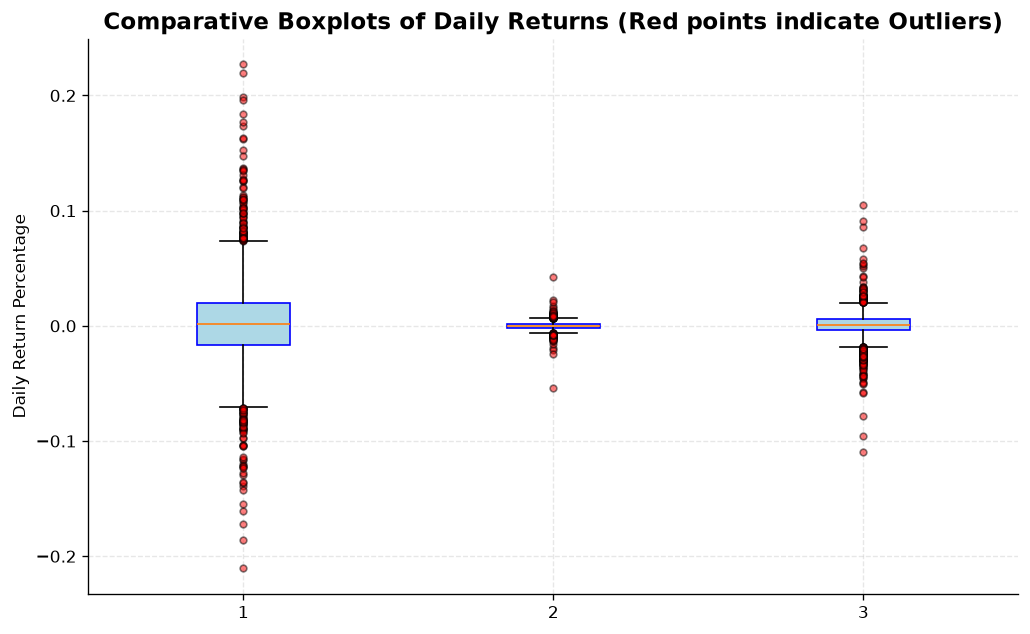

In [24]:
# Create a comparative boxplot to visually isolate the anomaly tails
plt.figure(figsize=(10, 6))
returns_data = [dataframes[ticker]['Daily_Return'].dropna() for ticker in tickers]

plt.boxplot(returns_data, label=tickers, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', color='blue'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))

plt.title("Comparative Boxplots of Daily Returns (Red points indicate Outliers)", fontsize=14, fontweight='bold')
plt.ylabel("Daily Return Percentage")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [25]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

for ticker in tickers:
    df = dataframes[ticker].dropna()
    
    print(f"\n{'='*50}")
    print(f" STATIONARITY TESTING FOR {ticker}")
    print(f"{'='*50}")
    
    # 1. Test on Raw Closing Prices
    price_result = adfuller(df['Close'])
    print(f"[Closing Price ADF Test]")
    print(f"  ↳ ADF Statistic: {price_result[0]:.4f}")
    print(f"  ↳ p-value:       {price_result[1]:.4f}")
    if price_result[1] <= 0.05:
        print("  ↳ Result: Stationary (No differencing needed for raw price)")
    else:
        print("  ↳ Result: NON-STATIONARY (Requires differencing / d > 0)")
        
    print("-" * 30)
    
    # 2. Test on Daily Returns
    return_result = adfuller(df['Daily_Return'].dropna())
    print(f"[Daily Returns ADF Test]")
    print(f"  ↳ ADF Statistic: {return_result[0]:.4f}")
    print(f"  ↳ p-value:       {return_result[1]:.4e}") # Using scientific notation if numbers are tiny
    if return_result[1] <= 0.05:
        print("  ↳ Result: STATIONARY (Ready for modeling!)")
    else:
        print("  ↳ Result: Non-Stationary (Needs further differencing)")


 STATIONARITY TESTING FOR TSLA
[Closing Price ADF Test]
  ↳ ADF Statistic: -1.0717
  ↳ p-value:       0.7262
  ↳ Result: NON-STATIONARY (Requires differencing / d > 0)
------------------------------
[Daily Returns ADF Test]
  ↳ ADF Statistic: -53.9719
  ↳ p-value:       0.0000e+00
  ↳ Result: STATIONARY (Ready for modeling!)

 STATIONARITY TESTING FOR BND
[Closing Price ADF Test]
  ↳ ADF Statistic: -1.0611
  ↳ p-value:       0.7303
  ↳ Result: NON-STATIONARY (Requires differencing / d > 0)
------------------------------
[Daily Returns ADF Test]
  ↳ ADF Statistic: -15.2161
  ↳ p-value:       5.5684e-28
  ↳ Result: STATIONARY (Ready for modeling!)

 STATIONARITY TESTING FOR SPY
[Closing Price ADF Test]
  ↳ ADF Statistic: 1.3193
  ↳ p-value:       0.9967
  ↳ Result: NON-STATIONARY (Requires differencing / d > 0)
------------------------------
[Daily Returns ADF Test]
  ↳ ADF Statistic: -17.5722
  ↳ p-value:       4.0463e-30
  ↳ Result: STATIONARY (Ready for modeling!)


In [27]:
import numpy as np


# Define standard assumptions
RISK_FREE_RATE_ANNUAL = 0.04  # Assuming a 4% risk-free rate (Treasury yields)
TRADING_DAYS_YEAR = 252

risk_metrics = {}

print(f"{'='*55}")
# Using standard text formatting for clarity and avoiding complex mathematical styles
print("          FOUNDATIONAL RISK METRICS REPORT")
print(f"{'='*55}\n")

for ticker in tickers:
    df = dataframes[ticker].dropna()
    returns = df['Daily_Return'].dropna()
    
    # 1. Calculate Value at Risk (VaR) using the Historical Method
    # 95% Confidence means looking at the 5th percentile of sorted returns
    var_95 = np.percentile(returns, 5)
    # 99% Confidence means looking at the 1st percentile of sorted returns
    var_99 = np.percentile(returns, 1)
    
    # 2. Calculate Annualized Sharpe Ratio
    mean_return_daily = returns.mean()
    volatility_daily = returns.std()
    
    # De-annualize risk-free rate to match daily returns
    rf_daily = RISK_FREE_RATE_ANNUAL / TRADING_DAYS_YEAR
    
    excess_return_daily = mean_return_daily - rf_daily
    sharpe_daily = excess_return_daily / volatility_daily if volatility_daily != 0 else 0
    sharpe_annualized = sharpe_daily * np.sqrt(TRADING_DAYS_YEAR)
    
    # 3. Calculate Annualized Volatility (for context)
    vol_annualized = volatility_daily * np.sqrt(TRADING_DAYS_YEAR)
    
    # Save metrics
    risk_metrics[ticker] = {
        "95% Daily VaR": f"{var_95 * 100:.2f}%",
        "99% Daily VaR": f"{var_99 * 100:.2f}%",
        "Annual Volatility": f"{vol_annualized * 100:.2f}%",
        "Annualized Sharpe Ratio": f"{sharpe_annualized:.2f}"
    }

# Convert dictionary to DataFrame for a beautiful, clean comparison table
metrics_df = pd.DataFrame(risk_metrics).T
display(metrics_df)

          FOUNDATIONAL RISK METRICS REPORT



,95% Daily VaR,99% Daily VaR,Annual Volatility,Annualized Sharpe Ratio
TSLA,-5.17%,-8.99%,57.18%,0.72
BND,-0.48%,-0.86%,5.31%,-0.38
SPY,-1.67%,-3.17%,17.65%,0.59
